In [39]:
import re

with open("Dante.txt", "r", encoding="utf-8") as f:
    text = f.read()

headers = list(re.finditer(r"CANTO\s+[IVXLCDM]+", text))

headers = headers[:34]

cantos = []
for i in range(len(headers)):
    start_idx = headers[i].start()
    if i < len(headers) - 1:
        end_idx = headers[i+1].start()
    else:
        end_idx = headers[-1].end() + 5000  # grab rest safely
    cantos.append(text[start_idx:end_idx])

print("Number of cantos:", len(cantos))

Number of cantos: 34


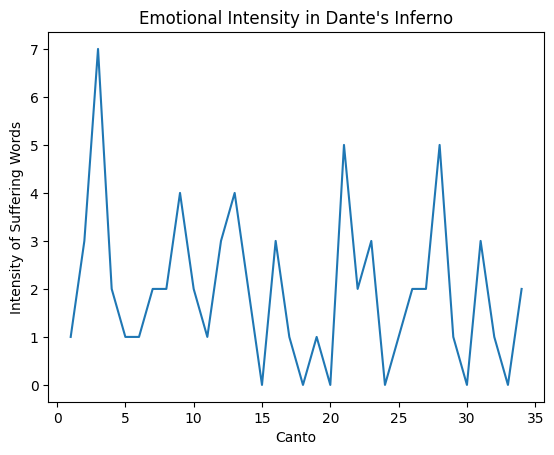

In [40]:
import matplotlib.pyplot as plt

dark_words = ["pain", "fear", "dark", "suffering", "torment", "death", "despair"]

scores = []

for canto in cantos:
    words = canto.lower().split()
    count = sum(words.count(w) for w in dark_words)
    scores.append(count)

# plot
plt.plot(range(1, 35), scores)
plt.xlabel("Canto")
plt.ylabel("Intensity of Suffering Words")
plt.title("Emotional Intensity in Dante's Inferno")
plt.show()

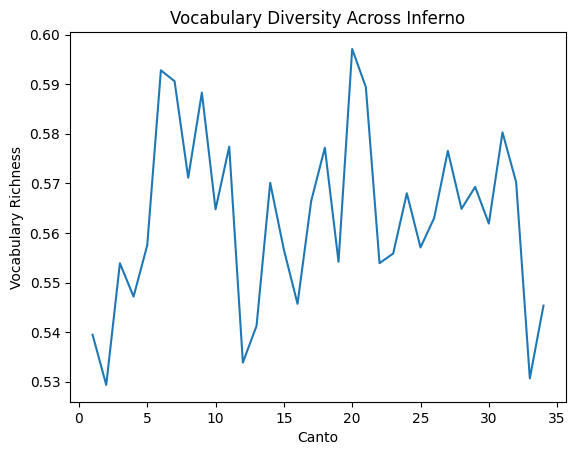

In [75]:
vocab_scores = []

for canto in cantos:
    words = canto.lower().split()
    unique = len(set(words))
    total = len(words)
    vocab_scores.append(unique / total)
plt.plot(range(1, 35), vocab_scores)
plt.xlabel("Canto")
plt.ylabel("Vocabulary Richness")
plt.title("Vocabulary Diversity Across Inferno")
plt.show()

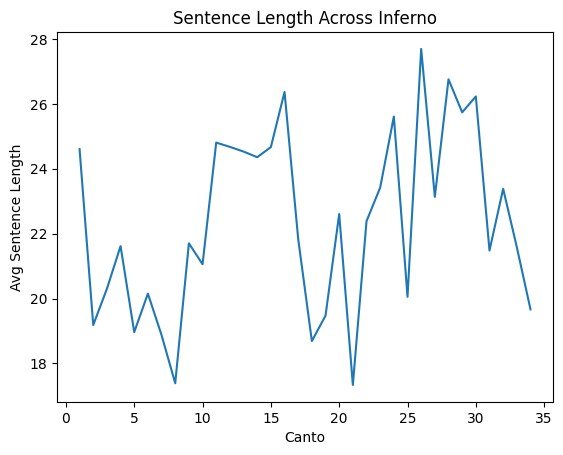

In [44]:
plt.plot(range(1, 35), sentence_lengths)
plt.xlabel("Canto")
plt.ylabel("Avg Sentence Length")
plt.title("Sentence Length Across Inferno")
plt.show()

In [45]:
violence_words = ["pain", "torment", "death", "blood", "suffering"]
fear_words = ["fear", "dread", "weeping", "cry", "terror"]
moral_words = ["sin", "justice", "god", "soul", "divine"]

violence_scores = []
fear_scores = []
moral_scores = []

for canto in cantos:
    words = canto.lower().split()
    
    violence_scores.append(sum(words.count(w) for w in violence_words))
    fear_scores.append(sum(words.count(w) for w in fear_words))
    moral_scores.append(sum(words.count(w) for w in moral_words))

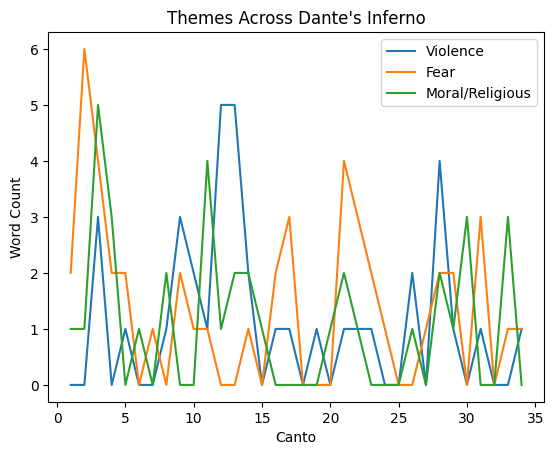

In [46]:
plt.plot(range(1, 35), violence_scores, label="Violence")
plt.plot(range(1, 35), fear_scores, label="Fear")
plt.plot(range(1, 35), moral_scores, label="Moral/Religious")

plt.xlabel("Canto")
plt.ylabel("Word Count")
plt.title("Themes Across Dante's Inferno")
plt.legend()
plt.show()

{'Intensity': {'Upper Hell': 2.3636363636363638, 'Violence': 2.1666666666666665, 'Fraud': 1.6923076923076923, 'Treachery': 1.5}, 'Vocab': {'Upper Hell': 0.5647650595612773, 'Violence': 0.5523395430492427, 'Fraud': 0.5683348336043904, 'Treachery': 0.5566435446807361}, 'SentenceLen': {'Upper Hell': 20.786478754293487, 'Violence': 24.404689230470083, 'Fraud': 23.00938155747429, 'Treachery': 21.52896307165566}}


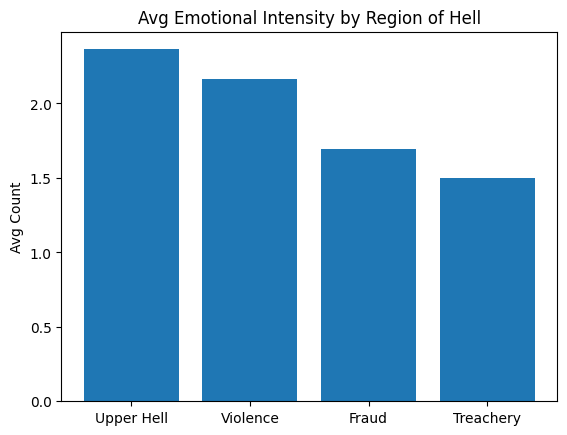

In [69]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# default stopwords
stop_words = text.ENGLISH_STOP_WORDS

# add your own
custom_stopwords = list(stop_words.union({
    "th", "ye", "thy", "thee", "thou", "unto", "shall", "shalt"
}))

vectorizer = TfidfVectorizer(
    stop_words=custom_stopwords,
    max_df=0.8,
    min_df=2
)

X = vectorizer.fit_transform(cantos)
feature_names = vectorizer.get_feature_names_out()

In [70]:
import numpy as np

canto_idx = 0  # change this to explore different cantos

row = X[canto_idx].toarray().flatten()

top_indices = row.argsort()[-5:][::-1]

top_words = [feature_names[i] for i in top_indices]

print(f"Canto {canto_idx+1} Top Words:", top_words)

Canto 1 Top Words: ['beast', 'aloft', 'love', 'animal', 'lead']


In [71]:
for i in [0, 10, 20, 30]:
    row = X[i].toarray().flatten()
    top_indices = row.argsort()[-5:][::-1]
    top_words = [feature_names[j] for j in top_indices]
    
    print(f"Canto {i+1}: {top_words}")

Canto 1: ['beast', 'aloft', 'love', 'animal', 'lead']
Canto 11: ['god', 'nature', 'fraud', 'force', 'second']
Canto 21: ['bridge', 'hooks', 'bespake', 'rock', 'lest']
Canto 31: ['giants', 'fain', 'caught', 'jove', 'doth']


In [72]:
top_words = []
top_scores = []

for i in range(len(cantos)):
    row = X[i].toarray().flatten()
    top_index = row.argmax()
    
    top_words.append(feature_names[top_index])
    top_scores.append(row[top_index])

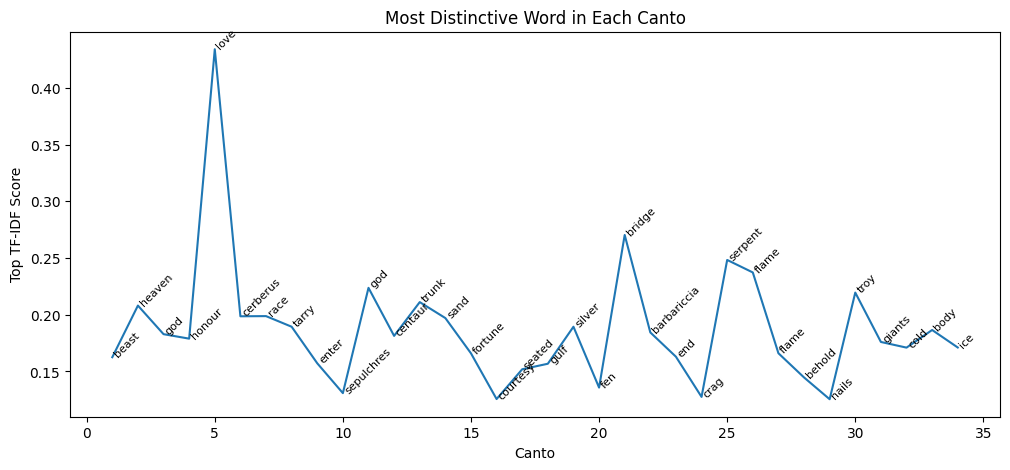

In [73]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(range(1, 35), top_scores)

for i, word in enumerate(top_words):
    plt.text(i+1, top_scores[i], word, fontsize=8, rotation=45)

plt.xlabel("Canto")
plt.ylabel("Top TF-IDF Score")
plt.title("Most Distinctive Word in Each Canto")
plt.show()

In [74]:
import pandas as pd

data = []

for i in range(len(cantos)):
    row = X[i].toarray().flatten()
    top_indices = row.argsort()[-3:][::-1]
    words = [feature_names[j] for j in top_indices]
    
    data.append({
        "Canto": i+1,
        "Top Words": ", ".join(words)
    })

df = pd.DataFrame(data)
df

,Canto,Top Words
0,1,"beast, aloft, love"
1,2,"heaven, hast, late"
2,3,"god, eternal, shore"
3,4,"honour, faith, child"
4,5,"love, read, pity"
5,6,"cerberus, heavy, shades"
6,7,"race, billow, church"
7,8,"tarry, entrance, inly"
8,9,"enter, heav, hid"
9,10,"sepulchres, st, return"
